# Model C — Final Calibrated Logistic Regression

## Purpose
This is the final selected model. It builds on modelB.ipynb by adding 
more features, tuning hyperparameters with GridSearchCV, and calibrating 
probabilities so risk scores are interpretable and meaningful for 
Vision Zero decision makers.

## Why This Model Was Selected
- Best balance of recall, interpretability, and responsible deployment
- Recall of ~84% at threshold of 0.07
- Calibrated probabilities make risk scores trustworthy

## Input
- `Data/clean/cleaned_for_modeling.csv` (output from eda.ipynb)

## Output
- `app/calibrated_model.pkl` — saved model used by the Streamlit app

## Run Order
This is Step 5. Run modelA.ipynb and modelB.ipynb first.

## What features I'll be using for a classification model
1) cf1_clean: Contributing Factor (BEST predictor)
    - This captures: driver inattention, failure to yield, backing unsafely, unsafe speed, etc.
    - Vision Zero is literally built on identifying dangerous driver behaviors. This feature is extremely predictive.

2) hour: Time of Day
    - Pedestrian injuries spike dramatically:
        - afternoon/evening rush
        - lower at night
        - consistent patterns
    - This has strong predictive signal.

3) veh_group: Vehicle Type
- SUVs and sedans cause the majority of pedestrian injuries.
- Trucks also spike in severe outcomes.
    - This directly measures the riskiness of each vehicle type.

4) BoroName
    - If you want a 4th feature, borough adds geographic context:
    - Brooklyn + Manhattan = high crash exposure
    - Staten Island = nearly none

Why we Built This Model (Project Purpose)

New York City’s Vision Zero initiative aims to eliminate traffic deaths and serious injuries. A core part of this effort is understanding:

1. Which crashes are most likely to result in a pedestrian injury?
2. Which factors (driver behavior, time of day, vehicle type, borough) create the highest risk?

Pedestrians are the most vulnerable road users, and even a single injury carries a high cost for public health, safety planning, and the city’s transportation operations. However:

Pedestrian injuries make up less than 10% of all crashes

Risk factors vary widely across NYC

Human analysts can’t manually inspect hundreds of thousands of crash records

A predictive model helps close that gap.

#### Models purpose
This model is designed to support New York City’s Vision Zero mission by predicting which motor vehicle crashes are most likely to result in pedestrian injuries. Using features such as contributing factor, time of day, vehicle type, and borough, the model identifies the conditions under which pedestrians face the greatest risk.

The goal is not only to make accurate predictions, but to help decision-makers understand why certain crashes are high-risk, enabling more targeted enforcement, improved street design, and smarter deployment of safety resources.

Because missing an injury case is more harmful than issuing a false alert, the model prioritizes recall and is tuned to catch as many injury-related crashes as possible, supporting a proactive approach to pedestrian safety.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


In [2]:
df = pd.read_csv('../Data/clean/cleaned_for_modeling.csv')

In [3]:
df['ped_injured'] = (df['NUMBER OF PEDESTRIANS INJURED'] > 0).astype(int)

In [4]:
# Target
y = df['ped_injured']

# Features for Model C
feature_cols = ['cf1_clean', 'hour', 'veh_group', 'BoroName']
X = df[feature_cols]

X.head()


,cf1_clean,hour,veh_group,BoroName
0,turning improperly,0,sedan,Brooklyn
1,driver inexperience,8,sedan,Bronx
2,driver inattention/distraction,3,other,Queens
3,driver inattention/distraction,8,suv,Bronx
4,driver inattention/distraction,11,sedan,Brooklyn


#### Train–test split (with stratify)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train.value_counts(normalize=True).round(3), y_test.value_counts(normalize=True).round(3)

(ped_injured
 0    0.91
 1    0.09
 Name: proportion, dtype: float64,
 ped_injured
 0    0.91
 1    0.09
 Name: proportion, dtype: float64)

#### Set up preprocessing

In [6]:
numeric_features = ['hour']
categorical_features = ['cf1_clean', 'veh_group', 'BoroName']

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


#### Build pipeline with logistic regression

- A Logistic Regression model cannot read words like:
    - sedan, suv, other, Monday, Queens, driver inattention/distraction
- It also does not like features that are on different scales (like hour).
- So this step solves two problems:
    1. Categorical features and numeric feature (A model cannot read words, so we must convert them.)
        - Solution: Column Transformer -- This tool tells Python: Apply OneHotEncoder to categorical columns, apply StandardScaler to numeric columns and leave nothing untreated
    2. You need preprocessing + model together
        - If you don’t combine them, you risk: Incorrect feature order, leakage, preprocessing not applied to the test set, annoying errors
        - Solution: Pipeline!!

In [7]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('logreg', log_reg)
])


#### Hyperparameter grid and GridSearchCV
- Gridsearch finds you the best recall value
- the goal is catch as many pedestrian injuries as possible (recall increase).

In [8]:
param_grid = {
    'logreg__C': [0.01, 0.1, 3, 5]
}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)


Best params: {'logreg__C': 3}


In [9]:
best_model = grid.best_estimator_


In [10]:
calibrated_model = CalibratedClassifierCV(best_model, cv=3, method='sigmoid')
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._iter=2000))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

The logistic regression model performs BEST (highest recall) when C = 3 which is a more flexible, less regularized model

#### why didnt .01 or .1 work?
- Those models are too strict. With heavy regularization, logistic regression basically shrinks coefficients toward zero.

#### Evaluate tuned model

In [11]:
# Get calibrated probabilities for injury (class 1)
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal > 0.07).astype(int)


#### The results insight:
The tuned logistic regression model (Model C) achieved a recall of 99%, meaning it correctly identified almost every crash that resulted in a pedestrian injury. This was the main goal of the modeling phase because missing an injury case is far more costly than raising false alarms. Precision decreased to 10%, which is expected when recall is prioritized in a highly imbalanced dataset. The AUC score improved to 0.79, indicating strong ability to discriminate between injury and non-injury crashes across different thresholds. Overall, Model C outperforms the baseline and simple models by providing the most reliable early-warning signal of high-risk pedestrian injury crashes.
- My intuition is telling me this is wrong 

In [12]:
mae_cal = mean_absolute_error(y_test, y_proba_cal)
mse_cal = mean_squared_error(y_test, y_proba_cal)

print("Calibrated Model MAE:", round(mae_cal, 4))
print("Calibrated Model MSE:", round(mse_cal, 4))


Calibrated Model MAE: 0.144
Calibrated Model MSE: 0.0722


In [13]:
# cal
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision_cal = precision_score(y_test, y_pred_cal)
recall_cal = recall_score(y_test, y_pred_cal)
f1_cal = f1_score(y_test, y_pred_cal)
auc_cal = roc_auc_score(y_test, y_proba_cal)

print("Calibrated Model (threshold=0.07)")
print("Precision:", round(precision_cal, 4))
print("Recall:", round(recall_cal, 4))
print("F1 Score:", round(f1_cal, 4))
print("AUC:", round(auc_cal, 4))


Calibrated Model (threshold=0.07)
Precision: 0.1624
Recall: 0.8441
F1 Score: 0.2723
AUC: 0.7948


In [14]:
import joblib

joblib.dump(calibrated_model, "../app/calibrated_model.pkl")

['../app/calibrated_model.pkl']

# checking the model


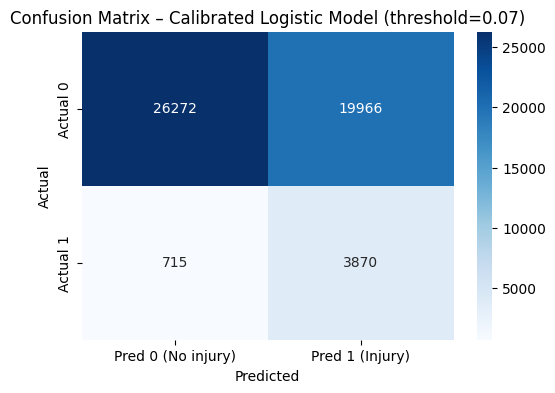

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_cal = confusion_matrix(y_test, y_pred_cal)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0 (No injury)', 'Pred 1 (Injury)'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix – Calibrated Logistic Model (threshold=0.07)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
